In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('/content/healthcare_data_cleaning_dataset.csv')

# First 5 records
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


Question:1 Missing Data Identification

Scenario:
 The hospital suspects incomplete patient records.

Task:

1. Identify missing values in each column

2. Calculate percentage of missing data



In [6]:
# Missing values count
missing_values = df.isnull().sum()

# Missing percentage
missing_percentage = (df.isnull().sum()/len(df))*100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

print(missing_df)



                    Missing Values  Percentage
Patient_ID                       0    0.000000
Age                            600   11.764706
Gender                           0    0.000000
City                             0    0.000000
Diagnosis                        0    0.000000
Hospital_Visits                  0    0.000000
Treatment_Cost                 593   11.627451
Insurance_Coverage               0    0.000000
Admission_Date                   0    0.000000


Question:2 Handling Missing Age

Scenario:
 Age is critical for medical analysis, but some values are missing.

Task:

1. Replace missing Age values with an appropriate method

2. Justify your choice (mean/median)

In [7]:
# Median Age
median_age = df['Age'].median()

# Replace missing values
df['Age'].fillna(median_age, inplace=True)

print(df['Age'].isnull().sum())

0


/tmp/ipykernel_947/494925331.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_age, inplace=True)


Question:3 Handling Missing Treatment Cost

Scenario:
 Treatment cost is highly skewed due to expensive treatments.

Task:

1. Handle missing Treatment_Cost values

2. Choose the correct imputation method and explain why

In [8]:
# Median Treatment Cost
median_cost = df['Treatment_Cost'].median()

# Fill Missing Values
df['Treatment_Cost'].fillna(median_cost, inplace=True)

print(df['Treatment_Cost'].isnull().sum())

0


/tmp/ipykernel_947/2368855943.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_cost, inplace=True)


Question:4 Duplicate Patient Records

Scenario:
 Some patient records were entered multiple times.

Task:

1. Identify duplicate rows




In [9]:
before_rows = df.shape[0]

duplicates = df.duplicated().sum()

print("Duplicate Rows =", duplicates)

Duplicate Rows = 99


Question:4

2. Remove duplicates
3. Compare dataset size before and after

In [10]:
df = df.drop_duplicates()

after_rows = df.shape[0]

print("Rows Before:", before_rows)
print("Rows After :", after_rows)
print("Removed Rows:", before_rows-after_rows)

Rows Before: 5100
Rows After : 5001
Removed Rows: 99


Question:5 Invalid Age Values (Data Quality Check)

Scenario:
 Some patients have unrealistic age values (e.g., >100 or <0).

Task:

1. Detect such records

2. Decide whether to remove or correct them



In [11]:
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]

print("Invalid Age Records:")
print(invalid_age)

Invalid Age Records:
Empty DataFrame
Columns: [Patient_ID, Age, Gender, City, Diagnosis, Hospital_Visits, Treatment_Cost, Insurance_Coverage, Admission_Date]
Index: []


In [12]:
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

print("Dataset Shape:", df.shape)

Dataset Shape: (5001, 9)


Question:6 Outlier Detection (Treatment Cost)

Scenario:
 Extreme treatment costs are affecting analysis.

Task:

1. Detect outliers using IQR method


In [13]:
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR

outliers = df[
    (df['Treatment_Cost'] < lower_limit) |
    (df['Treatment_Cost'] > upper_limit)
]

print("Number of Outliers =", len(outliers))

Number of Outliers = 50


Question:6

2. Display number of outliers

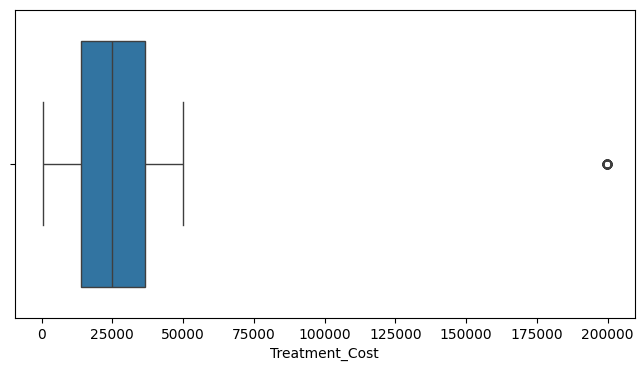

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['Treatment_Cost'])
plt.show()

Question:7 Outlier Treatment

Scenario:
The business team wants to retain all records.

Task:

1. Apply capping (Winsorization) on Treatment_Cost

2. Use 5th and 95th percentile



In [15]:
lower_cap = df['Treatment_Cost'].quantile(0.05)
upper_cap = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost_Capped'] = np.where(
    df['Treatment_Cost'] < lower_cap,
    lower_cap,
    np.where(
        df['Treatment_Cost'] > upper_cap,
        upper_cap,
        df['Treatment_Cost']
    )
)

df[['Treatment_Cost','Treatment_Cost_Capped']].head()

,Treatment_Cost,Treatment_Cost_Capped
0,41010.0,41010.0
1,12194.0,12194.0
2,45086.0,45086.0
3,40842.0,40842.0
4,9873.0,9873.0


Question:8 Transformation

Scenario:
 Treatment cost is highly skewed.

Task:

1. Apply log transformation



In [16]:
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost_Capped'])

df[['Treatment_Cost_Capped',
    'Log_Treatment_Cost']].head()

,Treatment_Cost_Capped,Log_Treatment_Cost
0,41010.0,10.621596
1,12194.0,9.408781
2,45086.0,10.716349
3,40842.0,10.617491
4,9873.0,9.197660


Question:8

2. Create a new column

3. Compare before vs after distribution

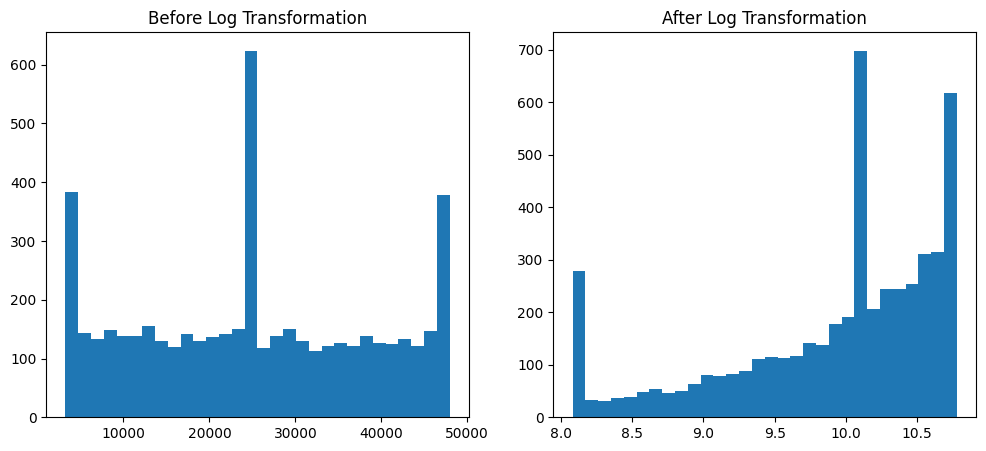

In [17]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(df['Treatment_Cost_Capped'], bins=30)
plt.title("Before Log Transformation")

plt.subplot(1,2,2)
plt.hist(df['Log_Treatment_Cost'], bins=30)
plt.title("After Log Transformation")

plt.show()

Question:9 Time-Based Missing Handling

Scenario:
 Admission dates should follow a logical sequence.

Task:

1. Sort data by Admission_Date


In [26]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values('Admission_Date')

Question:9

2. Apply forward fill or backward fill where appropriate

In [28]:
df = df.fillna(method='ffill')


/tmp/ipykernel_947/3984534036.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Question:9

3. Justify your choice

Ans:
   Forward Fill Method was used because the dataset contains time-based records. In such datasets, the most recent valid observation is often the best estimate for a missing value. Forward filling preserves the continuity of the data and avoids introducing unrealistic values. It is especially useful when measurements or patient information are expected to remain relatively stable over short periods of time.